In [22]:
import sys
sys.path.append("../")
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
from src.relaxers.quadratic_model_lin_approx import quadratic_model_lin_approx
from src.relaxers.quadratic_lin_approx_no_surrogate import quadratic_lin_approx_no_surrogate
from src.testers.classical_solve_lin_program import solve_lp
from src.testers.classical_solve_quad_program import solve_qcp
import matplotlib.pyplot as plt
import numpy as np

true_false = (True, False)

This notebook is for experimenting on with linear approximations to the toy problem or the GasNet-11 problem.

You can download the relevant GasNet-11 files from Sergey's emails.

Some conclusions:
- The condition number is stable with the bound constraints for the toy problem but goes to infinity without them (is there an eigenvalue of 0?)
- The condition number is a bit higher in general for the real problem but still manageable without the bound constraints.
- Most bound constraint parameters to the linear approximation don't affect the condition number. Some (N, lambda) are hard to check because the toy problem seems to have odd properties compared to the real problem. The condition number is linearly proportional to the number of linear constraints. The effect of if the coefficient is included in the surrogate is large and very different depending on toy vs. real.

In [24]:
# Whether to do an inner or outer approximation
OUTER_APPROXIMATION = True

# Whether the coefficient is part of the surrogate
COEFFICIENT_SURROGATE = True

# Whether to bound the surrogates with bound constraints.
SURROGATE_BOUND_BELOW = True
SURROGATE_BOUND_ABOVE = True

# Whether to divide by lambda in an inner approximation
REMOVE_DIVISION = False

In [25]:
# Put the original QCP into gurobi
qcp_value, qcp_time = solve_qcp(f_name="model11_quad.json")
print(qcp_value, qcp_time)

4692.145734343309 0.0019998550415039062


In [26]:
print(solve_lp(f_name="Model11_lp.json"))
print(solve_qcp(f_name="Model11_lp.json"))

(4587.929636019629, 0.0)
(4587.929636019691, 0.0)


In [27]:
errors = []
times = []

# Model may be infeasible if this is not big enough
# lin_cons_range = range(2, 101, 4)
lin_cons_range = range(20, 1001, 40)

for lin_cons in lin_cons_range:
    # quadratic_model_lin_approx(lin_cons, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
    #                             SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE,
    #                             f_name="model11_quad.json", remove_division=REMOVE_DIVISION)
    quadratic_lin_approx_no_surrogate(lin_cons, OUTER_APPROXIMATION,
                                        f_name="model11_quad.json", remove_division=REMOVE_DIVISION)
    val, time = solve_lp()
    if qcp_value is not None and val is not None:
        errors.append(val - qcp_value)
        times.append(time)

fig, (ax1, ax2) = plt.subplots(2, 1)
fig.supxlabel("linear constraints")
ax1.plot(lin_cons_range, errors, label="difference from final objective values")
ax2.plot(lin_cons_range, times, label="Solve times")
fig.legend()

print(errors[-1])
print(errors[2])

KeyboardInterrupt: 

-0.13961890079826844
-19.61007223614706


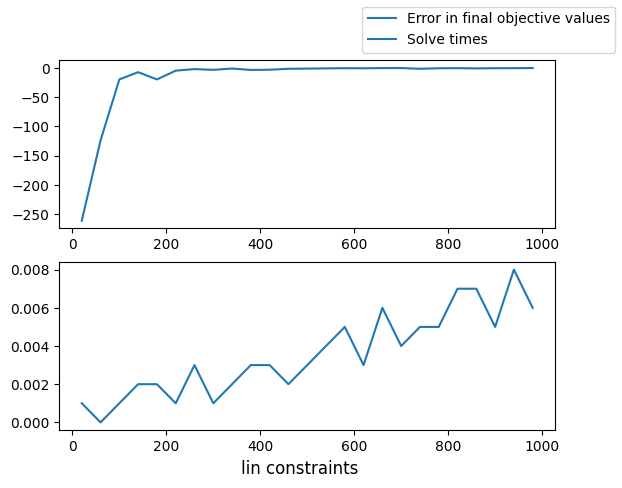

In [ ]:
# Tends to be infeasible for inner approximation
if OUTER_APPROXIMATION:
    rng = np.random.default_rng()

    errors = []
    times = []
    # lin_cons_range = range(2, 101, 4)
    lin_cons_range = range(20, 1001, 40)
    for lin_cons in lin_cons_range:
        # quadratic_model_lin_approx(lin_cons, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
        #                             SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE,
        #                             points_function=rng.uniform, remove_division=REMOVE_DIVISION,
        #                             f_name="model11_quad.json")
        quadratic_lin_approx_no_surrogate(lin_cons, OUTER_APPROXIMATION,
                                            points_function=rng.uniform, remove_division=REMOVE_DIVISION,
                                            f_name="model11_quad.json")
        val, time = solve_lp()
        if val is not None and qcp_value is not None:
            errors.append(val - qcp_value)
            times.append(time)

    fig, (ax1, ax2) = plt.subplots(2, 1)
    fig.supxlabel("lin constraints")
    ax1.plot(lin_cons_range, errors, label="Error in final objective values")
    ax2.plot(lin_cons_range, times, label="Solve times")
    fig.legend()

    print(errors[-1])
    print(errors[2])

In [ ]:
concat = 1.3

def np_uniform_bunch_low(lower: float, upper: float, num: int):
    return np.linspace(lower, lower + ((upper - lower)/concat), num)

def np_uniform_bunch_high(lower: float, upper: float, num: int):
    return np.linspace(upper - ((upper - lower) / concat), upper, num)

def np_uniform_bunch_middle(lower: float, upper: float, num: int):
    return np.linspace(upper - ((upper - lower) / (2*concat)), lower + ((upper - lower)/(2*concat)), num)

-0.02449565803999576
-3.3302283599869043


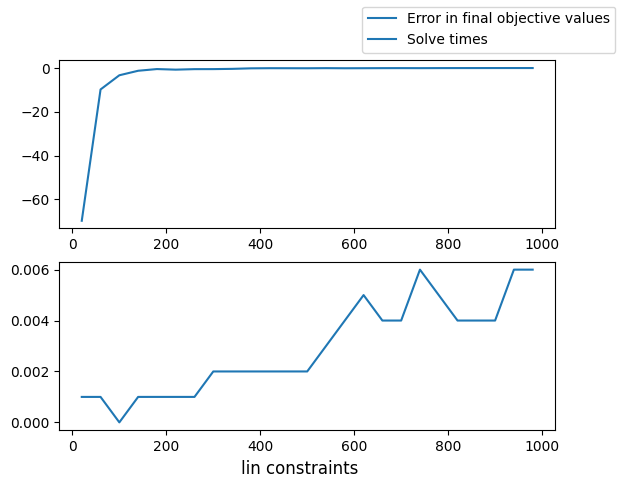

In [ ]:
errors = []
times = []
# lin_cons_range = range(2, 101, 4)
lin_cons_range = range(20, 1001, 40)
for lin_cons in lin_cons_range:
    # quadratic_model_lin_approx(lin_cons, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
    #                             SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE,
    #                             points_function=np_uniform_bunch_low, remove_division=REMOVE_DIVISION,
    #                             f_name="model11_quad.json")
    quadratic_lin_approx_no_surrogate(lin_cons, OUTER_APPROXIMATION,
                                        points_function=np_uniform_bunch_low, remove_division=REMOVE_DIVISION,
                                        f_name="model11_quad.json")
    val, time = solve_lp()
    if val is not None and qcp_value is not None:
        errors.append(val - qcp_value)
        times.append(time)

fig, (ax1, ax2) = plt.subplots(2, 1)
fig.supxlabel("lin constraints")
ax1.plot(lin_cons_range, errors, label="Error in final objective values")
ax2.plot(lin_cons_range, times, label="Solve times")
fig.legend()

print(errors[-1])
print(errors[2])

-0.05631800124592701
-4.558142795255662


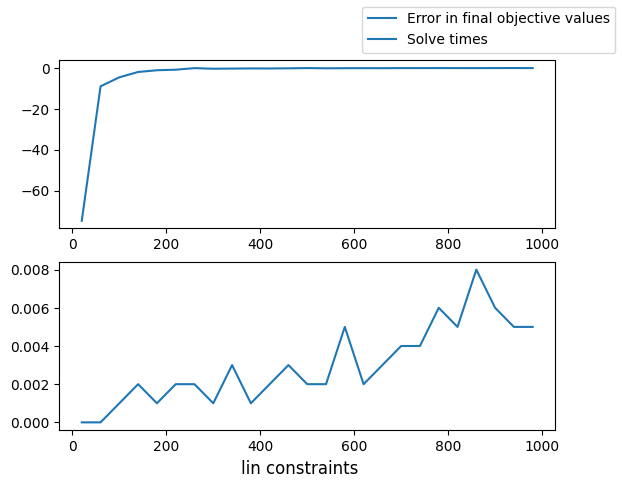

In [ ]:
errors = []
times = []
# lin_cons_range = range(2, 101, 4)
lin_cons_range = range(20, 1001, 40)
for lin_cons in lin_cons_range:
    # quadratic_model_lin_approx(lin_cons, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
    #                             SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE,
    #                             points_function=np_uniform_bunch_high, remove_division=REMOVE_DIVISION,
    #                             f_name="model11_quad.json")
    quadratic_lin_approx_no_surrogate(lin_cons, OUTER_APPROXIMATION,
                                        points_function=np_uniform_bunch_high, remove_division=REMOVE_DIVISION,
                                        f_name="model11_quad.json")
    val, time = solve_lp()
    if val is not None and qcp_value is not None:
        errors.append(val - qcp_value)
        times.append(time)

fig, (ax1, ax2) = plt.subplots(2, 1)
fig.supxlabel("lin constraints")
ax1.plot(lin_cons_range, errors, label="Error in final objective values")
ax2.plot(lin_cons_range, times, label="Solve times")
fig.legend()

print(errors[-1])
print(errors[2])

-0.00299677989914926
-0.20622678183372045


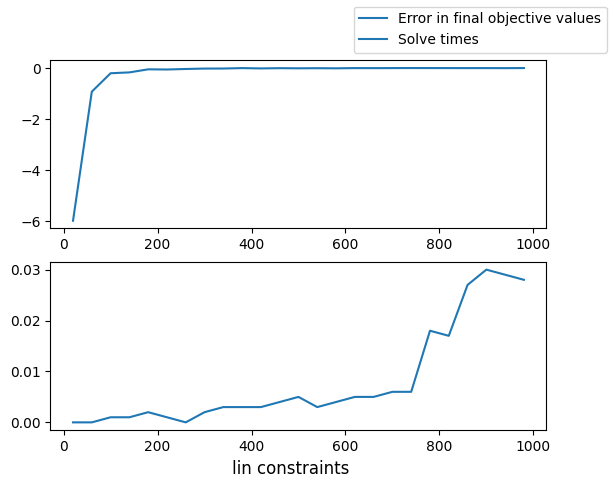

In [ ]:
errors = []
times = []
# lin_cons_range = range(2, 101, 4)
lin_cons_range = range(20, 1001, 40)
for lin_cons in lin_cons_range:
    # quadratic_model_lin_approx(lin_cons, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
    #                             SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE,
    #                             points_function=np_uniform_bunch_middle, remove_division=REMOVE_DIVISION,
    #                             f_name="model11_quad.json")
    quadratic_lin_approx_no_surrogate(lin_cons, OUTER_APPROXIMATION,
                                        points_function=np_uniform_bunch_middle, remove_division=REMOVE_DIVISION,
                                        f_name="model11_quad.json")
    val, time = solve_lp()
    if val is not None and qcp_value is not None:
        errors.append(val - qcp_value)
        times.append(time)

fig, (ax1, ax2) = plt.subplots(2, 1)
fig.supxlabel("lin constraints")
ax1.plot(lin_cons_range, errors, label="Error in final objective values")
ax2.plot(lin_cons_range, times, label="Solve times")
fig.legend()

print(errors[-1])
print(errors[2])

np.float64(1.1780780780780782)

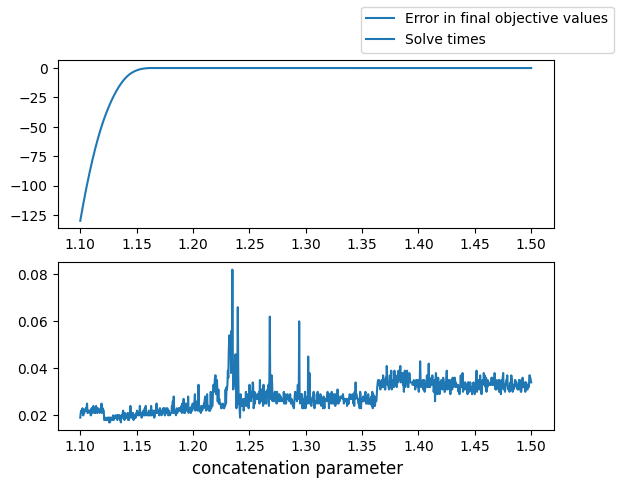

In [30]:
points = np.linspace(1.1, 1.5, 1000, endpoint=True)
LIN_CONSTRAINTS = 1000

errors = []
times = []
for concat in points:
    
    def np_uniform_bunch_middle(lower: float, upper: float, num: int):
        return np.linspace(upper - ((upper - lower) / (2*concat)), lower + ((upper - lower)/(2*concat)), num)
    
    # quadratic_model_lin_approx(LIN_CONSTRAINTS, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
    #                             SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE,
    #                             points_function=np_uniform_bunch_middle, remove_division=REMOVE_DIVISION,
    #                             f_name="model11_quad.json")
    quadratic_lin_approx_no_surrogate(LIN_CONSTRAINTS, OUTER_APPROXIMATION,
                                        points_function=np_uniform_bunch_middle, remove_division=REMOVE_DIVISION,
                                        f_name="model11_quad.json")
    val, time = solve_lp()
    if val is not None and qcp_value is not None:
        errors.append(val - qcp_value)
        times.append(time)

fig, (ax1, ax2) = plt.subplots(2, 1)
fig.supxlabel("concatenation parameter")
ax1.plot(points, errors, label="Error in final objective values")
ax2.plot(points, times, label="Solve times")
fig.legend()

points[np.argmin(np.abs(errors))]